In [24]:
import numpy as np
import joblib
import os
import warnings
from sklearn.exceptions import ConvergenceWarning
import time

# 1. Scikit-Learn 평가 도구 임포트
from scipy.ndimage import rotate, shift, zoom
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone

# 불필요한 경고 메시지 숨기기
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

print("--- 1. 평가에 필요한 모듈 로드 완료 ---")

--- 1. 평가에 필요한 모듈 로드 완료 ---


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Keras의 Original MNIST 데이터 로드
print("--- 1. Keras Original MNIST 데이터 로딩 ---")
# Keras가 없으면 Scikit-learn의 fetch_openml을 대안으로 사용
print("\n--- (대안) Scikit-Learn의 MNIST 데이터 로딩 ---")
from sklearn.datasets import fetch_openml
mnist_sklearn = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
# Scikit-learn은 (70000, 784)이므로 (N, 28, 28)로 reshape
x_train_keras = mnist_sklearn.data / 255
y_train_keras = mnist_sklearn.target.astype(np.uint8)
print(f"  > Scikit-learn MNIST 로드 성공. X_shape: {x_train_keras.shape}, y_shape: {y_train_keras.shape}")

keras = True

--- 1. Keras Original MNIST 데이터 로딩 ---

--- (대안) Scikit-Learn의 MNIST 데이터 로딩 ---
  > Scikit-learn MNIST 로드 성공. X_shape: (70000, 784), y_shape: (70000,)


In [26]:
import glob
import os

# --- 2. 파일 목록 정의 (자동 로드) ---
# 'train code' 폴더 내의 패턴에 맞는 모든 .joblib 파일을 찾습니다.
# 예: train code 폴더 안의 "..._best_0-1.joblib"로 끝나는 모든 파일
model_search_pattern = 'train code/0-1/*'
model_files = sorted(glob.glob(model_search_pattern))

# 파일이 제대로 찾아졌는지 확인
print(f"--- 총 {len(model_files)}개의 모델 파일을 찾았습니다 ---")
for f in model_files:
    print(f" -> {f}")

--- 총 8개의 모델 파일을 찾았습니다 ---
 -> train code/0-1/decision_tree_mnist_best_0-1.joblib
 -> train code/0-1/gradient_boosting_mnist_best_0-1.joblib
 -> train code/0-1/knn_mnist_best_0-1.joblib
 -> train code/0-1/logistic_mnist_best_0-1.joblib
 -> train code/0-1/mlp_classifier_mnist_best_0-1.joblib
 -> train code/0-1/random_forest_mnist_best_0-1.joblib
 -> train code/0-1/sgd_mnist_best_0-1.joblib
 -> train code/0-1/svm_mnist_best_0-1.joblib


In [27]:
# --- 3. Hand-made 테스트 데이터 로드 ---
print(f"\n--- 2. Hand-made 테스트 데이터 '{handmade_data_file}' 로드 ---")

if not os.path.exists(handmade_data_file):
    print(f"[오류] 테스트 데이터 '{handmade_data_file}'을 찾을 수 없습니다!")
    print("-> 이전 단계에서 데이터 병합 및 저장을 먼저 실행하세요.")
else:
    with np.load(handmade_data_file, allow_pickle=True) as data:
        print(data)
        if 'img' in data and 'label' in data:
            X_test = data['img']
            y_test = data['label']
        elif 'x_train' in data and 'y_train' in data:
            X_test = data['x_train']
            y_test = data['y_train']
        elif 'images' in data and 'labels' in data:
            X_test = data['images']
            y_test = data['labels']
        else:
            X_test = data['X']
            y_test = data['y'] # 이 y_test가 "실제 정답"
            
X_test = X_test.reshape(-1, 784)

if keras:
    X_test = x_train_keras
    y_test = y_train_keras

print(f"  > 테스트 데이터 로드 성공. X_test: {X_test.shape}, y_test: {y_test.shape}")


--- 2. Hand-made 테스트 데이터 'data/combined_mnist_1to32.npz' 로드 ---
NpzFile 'data/combined_mnist_1to32.npz' with keys: img, label
  > 테스트 데이터 로드 성공. X_test: (70000, 784), y_test: (70000,)


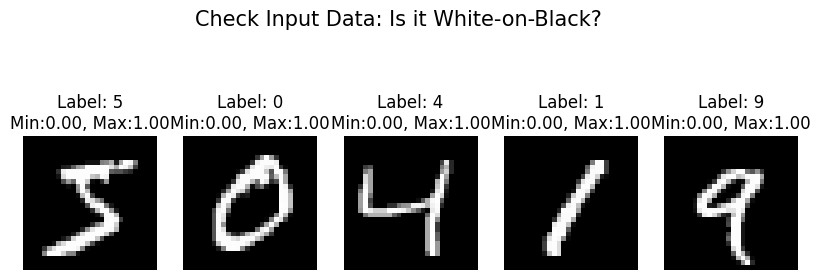

In [28]:
import matplotlib.pyplot as plt

# 1. 데이터 샘플 시각화 (모델에 들어가기 직전 상태 확인)
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # reshape해서 이미지로 복원
    img = X_test[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_test[i]}\nMin:{img.min():.2f}, Max:{img.max():.2f}")
    plt.axis('off')
plt.suptitle("Check Input Data: Is it White-on-Black?", fontsize=15)
plt.show()

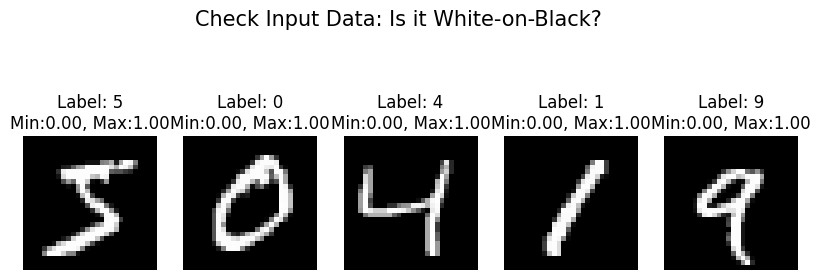


--- 3. 8개 모델 성능 평가 시작 ---

 [1/8] 평가 중: train code/0-1/decision_tree_mnist_best_0-1.joblib
  > 예측 완료 (소요 시간: 0.0819초)
  > **Accuracy (정확도): 95.22%**

  --- Classification Report (정밀도/재현율/F1) ---
              precision    recall  f1-score   support

           0     0.9716    0.9729    0.9723      6903
           1     0.9881    0.9769    0.9824      7877
           2     0.9461    0.9461    0.9461      6990
           3     0.9545    0.9289    0.9415      7141
           4     0.9392    0.9555    0.9473      6824
           5     0.9192    0.9460    0.9324      6313
           6     0.9590    0.9623    0.9607      6876
           7     0.9666    0.9565    0.9615      7293
           8     0.9290    0.9323    0.9307      6825
           9     0.9419    0.9416    0.9418      6958

    accuracy                         0.9522     70000
   macro avg     0.9515    0.9519    0.9517     70000
weighted avg     0.9524    0.9522    0.9523     70000


 [2/8] 평가 중: train code/0-1/gradient_boostin

In [30]:
import matplotlib.pyplot as plt

# 1. 데이터 샘플 시각화 (모델에 들어가기 직전 상태 확인)
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # reshape해서 이미지로 복원
    img = X_test[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_test[i]}\nMin:{img.min():.2f}, Max:{img.max():.2f}")
    plt.axis('off')
plt.suptitle("Check Input Data: Is it White-on-Black?", fontsize=15)
plt.show()

print("\n--- 3. 8개 모델 성능 평가 시작 ---")

results = []

for i, model_name in enumerate(model_files):
    print(f"\n=============================================")
    print(f" [{i+1}/{len(model_files)}] 평가 중: {model_name}")
    print(f"=============================================")
    
    if not os.path.exists(model_name):
        print(f"  [오류] 모델 파일 '{model_name}'을 찾을 수 없습니다! 'run_all.sh'를 먼저 실행하세요.")
        continue
        
    # 모델 로드
    model = joblib.load(model_name)
    
    # 예측 수행
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # 평가
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))
    
    print(f"  > 예측 완료 (소요 시간: {pred_time:.4f}초)")
    print(f"  > **Accuracy (정확도): {accuracy * 100:.2f}%**")
    
    print("\n  --- Classification Report (정밀도/재현율/F1) ---")
    print(report)
    
    # (수정) 예측 결과(y_pred)도 함께 저장
    results.append({
        'name': model_name.replace('train code/pipeline/base/', ''),
        'accuracy': accuracy,
        'cm': cm,
        'y_pred': y_pred  # 오류 분석을 위해 예측값 저장
    })

In [31]:
# --- 5. 최종 요약 및 Confusion Matrix 시각화 ---
print("\n--- 4. 최종 성능 요약 (Accuracy 기준 내림차순) ---")

# 정확도 기준으로 결과 정렬
results_sorted = sorted(results, key=lambda x: x['accuracy'], reverse=True)

for res in results_sorted:
    print(f"  - {res['name']:<25} | Accuracy: {res['accuracy'] * 100:.2f}%")

print("\n--- 5. 8개 모델 Confusion Matrix 시각화 ---")

# 2x4 격자로 8개 Confusion Matrix 그리기
fig_cm, axes_cm = plt.subplots(2, 4, figsize=(22, 10))
fig_cm.suptitle("Confusion Matrices: Original Models vs. Hand-made Data", fontsize=20)

for i, res in enumerate(results):
    ax = axes_cm.flat[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'], display_labels=np.arange(10))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{res['name']}\nAccuracy: {res['accuracy']:.3f}")
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

output_image_file = 'all_confusion_matrices.png'
plt.savefig(output_image_file)
print(f"\n[성공] 8개 모델의 혼동 행렬을 '{output_image_file}'로 저장했습니다.")
plt.close(fig_cm) # 메모리 해제


--- 4. 최종 성능 요약 (Accuracy 기준 내림차순) ---
  - train code/0-1/gradient_boosting_mnist_best_0-1.joblib | Accuracy: 100.00%
  - train code/0-1/knn_mnist_best_0-1.joblib | Accuracy: 100.00%
  - train code/0-1/random_forest_mnist_best_0-1.joblib | Accuracy: 99.97%
  - train code/0-1/mlp_classifier_mnist_best_0-1.joblib | Accuracy: 99.77%
  - train code/0-1/decision_tree_mnist_best_0-1.joblib | Accuracy: 95.22%
  - train code/0-1/logistic_mnist_best_0-1.joblib | Accuracy: 93.46%
  - train code/0-1/svm_mnist_best_0-1.joblib | Accuracy: 92.64%
  - train code/0-1/sgd_mnist_best_0-1.joblib | Accuracy: 91.96%

--- 5. 8개 모델 Confusion Matrix 시각화 ---

[성공] 8개 모델의 혼동 행렬을 'all_confusion_matrices.png'로 저장했습니다.
